# Evaluación de modelos para la detección del punto de cambio en trayectorias de difusión anómala

Este cuaderno presenta una comparación final de cuatro arquitecturas entrenadas para estimar el punto de cambio en trayectorias sintéticas de difusión anómala: **LSTM**, **ConvLSTM**, **Transformer** y **ConvTransformer**. La validación se realiza con el mismo protocolo de datos para que las diferencias observadas dependan del comportamiento de cada modelo y no de cambios en el conjunto de prueba.

La evaluación responde a tres puntos solicitados por el profesor:

1. confirmar cuántas trayectorias se usaron para entrenamiento, validación y prueba;
2. comparar el rendimiento global de cada arquitectura;
3. analizar los resultados para cada transición ordenada entre modelos de difusión, por ejemplo **ATTM → CTRW**, **CTRW → LW** o **FBM → SBM**.


## Protocolo de validación

Se evalúa una tarea de regresión supervisada donde la variable objetivo es la posición temporal de un único punto de cambio. Cada trayectoria tiene longitud fija:

$$
L = 100.
$$

Cada muestra se construye concatenando dos fragmentos. El primer fragmento procede de un modelo de difusión anómala $M_1$ y el segundo de un modelo $M_2$. Los modelos considerados son:

$$
\mathcal{M}=\{\mathrm{ATTM},\mathrm{CTRW},\mathrm{FBM},\mathrm{LW},\mathrm{SBM}\}.
$$

Solo se consideran transiciones entre modelos distintos:

$$
M_1 
eq M_2.
$$

Por tanto, el número total de transiciones ordenadas es:

$$
|\mathcal{M}|\,(|\mathcal{M}|-1)=5\times4=20.
$$

El conjunto de datos se organizó con la escala solicitada: **200.000 trayectorias para entrenamiento**, **20.000 para validación** y **200.000 para prueba**. El conjunto de prueba está equilibrado, con exactamente:

$$
10\,000 \text{ trayectorias por transición}.
$$

Esto produce:

$$
20 \text{ transiciones} \times 10\,000 \text{ trayectorias}=200\,000 \text{ trayectorias de prueba}.
$$

Los cuatro modelos se comparan sobre el mismo conjunto de test. Esta decisión permite atribuir las diferencias de rendimiento a la arquitectura utilizada y no a variaciones en los datos de evaluación.

La posición real del punto de cambio se denota por:

$$
\tau.
$$

La posición estimada por el modelo se denota por:

$$
\hat{\tau}.
$$

El error de localización para una trayectoria individual se define como:

$$
e_i = \hat{\tau}_i - \tau_i.
$$

El error absoluto asociado es:

$$
|e_i| = |\hat{\tau}_i - \tau_i|.
$$

Para evaluar el rendimiento global se usan dos métricas. La primera es el error absoluto medio:

$$
\operatorname{MAE}=\frac{1}{N}\sum_{i=1}^{N}|\hat{\tau}_i-\tau_i|.
$$

La segunda es la raíz del error cuadrático medio:

$$
\operatorname{RMSE}=\sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat{\tau}_i-\tau_i)^2}.
$$

El **MAE** mide el error medio en puntos temporales y se interpreta de forma directa. El **RMSE** penaliza más los errores grandes, por lo que ayuda a detectar si un modelo presenta fallos puntuales importantes.

La validación se realiza en dos niveles. Primero se comparan las arquitecturas de forma global. Después se estudian los errores por transición ordenada $M_1 \rightarrow M_2$, ya que la dificultad del problema no es la misma para todas las parejas de modelos de difusión.


In [1]:

from pathlib import Path
from io import StringIO

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

LENGTH = 100
MIN_SEGMENT_LENGTH = 20
DIFFUSION_MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
MODEL_ORDER = ["LSTM", "ConvLSTM", "Transformer", "ConvTransformer"]
METRIC_ORDER = ["MAE", "RMSE"]
REFERENCE_MODEL = "ConvTransformer"
ORDERED_TRANSITIONS = [(m1, m2) for m1 in DIFFUSION_MODELS for m2 in DIFFUSION_MODELS if m1 != m2]
TRANSITION_LABELS = [f"{m1} → {m2}" for m1, m2 in ORDERED_TRANSITIONS]

# Ruta relativa recomendada para GitHub. Si se ejecuta desde la carpeta notebooks,
# se busca la carpeta de datos en la raíz del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_changepoint_andi"

RESULT_DIRS = {
    "LSTM": PROJECT_ROOT / "lstm_results_final",
    "ConvLSTM": PROJECT_ROOT / "convlstm_results_final",
    "Transformer": PROJECT_ROOT / "transformer_results_final",
    "ConvTransformer": PROJECT_ROOT / "convtransformer_results_final",
}

FILE_PREFIX = {
    "LSTM": "lstm",
    "ConvLSTM": "convlstm",
    "Transformer": "transformer",
    "ConvTransformer": "convtransformer",
}

FIG_DIR = PROJECT_ROOT / "final_validation_figures"
FIG_DIR.mkdir(exist_ok=True)

embedded_global_csv = '''model,metric,value_in_points
LSTM,MAE,7.717000
LSTM,RMSE,11.706256
Transformer,MAE,11.411690
Transformer,RMSE,15.186792
ConvLSTM,MAE,8.708155
ConvLSTM,RMSE,12.575907
ConvTransformer,MAE,7.203850
ConvTransformer,RMSE,11.626196'''
embedded_pair_csv = '''model,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
LSTM,CTRW → LW,CTRW,LW,10000,3.6942,5.796827,3.0,0.4276
LSTM,LW → CTRW,LW,CTRW,10000,3.9594,6.259073,3.0,0.6686
LSTM,ATTM → LW,ATTM,LW,10000,5.3890,8.578706,3.0,0.0900
LSTM,LW → ATTM,LW,ATTM,10000,5.5924,8.923788,3.0,1.6744
LSTM,LW → SBM,LW,SBM,10000,5.9257,9.451100,3.0,1.2311
LSTM,SBM → LW,SBM,LW,10000,6.1974,9.658809,4.0,-0.4278
LSTM,CTRW → FBM,CTRW,FBM,10000,6.2627,10.085747,3.0,1.0629
LSTM,CTRW → SBM,CTRW,SBM,10000,6.2720,9.886172,4.0,1.5056
LSTM,LW → FBM,LW,FBM,10000,6.3673,10.201495,3.0,1.7921
LSTM,FBM → LW,FBM,LW,10000,6.4348,10.169130,4.0,-0.4942
LSTM,FBM → CTRW,FBM,CTRW,10000,6.5518,9.990035,4.0,-0.0298
LSTM,SBM → CTRW,SBM,CTRW,10000,6.7041,10.135211,4.0,0.0325
LSTM,CTRW → ATTM,CTRW,ATTM,10000,7.0212,11.313063,4.0,1.1212
LSTM,ATTM → CTRW,ATTM,CTRW,10000,8.7119,12.822796,5.0,-1.0103
LSTM,ATTM → FBM,ATTM,FBM,10000,10.9233,14.959703,7.0,0.1515
LSTM,FBM → ATTM,FBM,ATTM,10000,10.9485,14.933610,8.0,1.1915
LSTM,ATTM → SBM,ATTM,SBM,10000,11.4405,15.417668,8.0,0.3667
LSTM,FBM → SBM,FBM,SBM,10000,11.7491,15.571220,9.0,0.1823
LSTM,SBM → ATTM,SBM,ATTM,10000,11.9398,15.803860,9.0,1.4590
LSTM,SBM → FBM,SBM,FBM,10000,12.2549,15.921599,9.0,0.9129
Transformer,CTRW → LW,CTRW,LW,10000,6.7944,10.134890,4.0,0.1926
Transformer,LW → CTRW,LW,CTRW,10000,7.7835,11.160049,5.0,1.4515
Transformer,CTRW → FBM,CTRW,FBM,10000,9.6121,13.501389,6.0,0.6863
Transformer,ATTM → LW,ATTM,LW,10000,9.8485,13.634907,7.0,-0.3591
Transformer,CTRW → SBM,CTRW,SBM,10000,10.1883,13.947018,7.0,1.7927
Transformer,FBM → CTRW,FBM,CTRW,10000,10.2920,13.951136,7.0,0.1610
Transformer,CTRW → ATTM,CTRW,ATTM,10000,10.5892,14.556985,7.0,1.1018
Transformer,LW → ATTM,LW,ATTM,10000,10.7336,14.342099,8.0,2.8650
Transformer,FBM → LW,FBM,LW,10000,10.8929,14.716627,8.0,-0.7311
Transformer,LW → FBM,LW,FBM,10000,10.9626,14.904241,8.0,1.2796
Transformer,SBM → CTRW,SBM,CTRW,10000,11.0017,14.704214,8.0,-0.3009
Transformer,LW → SBM,LW,SBM,10000,11.8325,15.437872,9.0,2.5561
Transformer,SBM → LW,SBM,LW,10000,12.1187,15.888741,9.0,-1.9435
Transformer,ATTM → CTRW,ATTM,CTRW,10000,12.2454,16.212181,9.0,-0.9016
Transformer,ATTM → FBM,ATTM,FBM,10000,12.7109,16.343307,10.0,-0.3975
Transformer,FBM → ATTM,FBM,ATTM,10000,13.0632,16.559179,11.0,1.2116
Transformer,SBM → FBM,SBM,FBM,10000,13.9546,17.326258,12.0,-0.5946
Transformer,FBM → SBM,FBM,SBM,10000,14.0588,17.397534,12.0,1.3042
Transformer,ATTM → SBM,ATTM,SBM,10000,14.5417,17.948022,13.0,1.4471
Transformer,SBM → ATTM,SBM,ATTM,10000,15.0092,18.322041,13.0,0.4946
ConvLSTM,CTRW → LW,CTRW,LW,10000,4.3466,6.481543,3.0,1.8356
ConvLSTM,LW → CTRW,LW,CTRW,10000,4.8312,7.213903,3.0,2.0410
ConvLSTM,ATTM → LW,ATTM,LW,10000,6.0193,9.084784,4.0,1.2691
ConvLSTM,LW → ATTM,LW,ATTM,10000,6.7074,10.107769,4.0,2.8158
ConvLSTM,SBM → LW,SBM,LW,10000,6.9712,10.382110,4.0,0.3420
ConvLSTM,CTRW → FBM,CTRW,FBM,10000,6.9781,10.652901,4.0,2.1685
ConvLSTM,LW → SBM,LW,SBM,10000,7.0311,10.661731,4.0,2.2587
ConvLSTM,CTRW → SBM,CTRW,SBM,10000,7.0919,10.647145,4.0,2.9309
ConvLSTM,FBM → LW,FBM,LW,10000,7.3253,11.021629,5.0,0.0605
ConvLSTM,FBM → CTRW,FBM,CTRW,10000,7.4510,10.677678,5.0,1.4484
ConvLSTM,LW → FBM,LW,FBM,10000,7.6929,11.681973,5.0,2.7093
ConvLSTM,SBM → CTRW,SBM,CTRW,10000,7.7171,11.059941,5.0,1.2699
ConvLSTM,CTRW → ATTM,CTRW,ATTM,10000,7.9199,11.984402,5.0,2.3693
ConvLSTM,ATTM → CTRW,ATTM,CTRW,10000,9.8587,13.867296,6.0,0.0081
ConvLSTM,ATTM → FBM,ATTM,FBM,10000,11.7260,15.566772,9.0,0.8774
ConvLSTM,FBM → ATTM,FBM,ATTM,10000,12.0001,15.733013,9.0,2.0523
ConvLSTM,ATTM → SBM,ATTM,SBM,10000,12.8198,16.488008,10.0,1.6940
ConvLSTM,FBM → SBM,FBM,SBM,10000,13.0117,16.537355,11.0,1.3755
ConvLSTM,SBM → FBM,SBM,FBM,10000,13.2694,16.754898,11.0,0.8274
ConvLSTM,SBM → ATTM,SBM,ATTM,10000,13.3944,17.026039,11.0,1.6464
ConvTransformer,CTRW → LW,CTRW,LW,10000,2.6138,5.232648,1.0,-0.0180
ConvTransformer,LW → CTRW,LW,CTRW,10000,2.9581,5.695059,1.0,-0.3559
ConvTransformer,ATTM → LW,ATTM,LW,10000,4.4349,8.225236,2.0,-0.1949
ConvTransformer,LW → ATTM,LW,ATTM,10000,4.9101,8.699523,2.0,0.6905
ConvTransformer,LW → SBM,LW,SBM,10000,5.1645,9.091969,2.0,0.2799
ConvTransformer,SBM → LW,SBM,LW,10000,5.4515,9.433085,2.0,-0.6251
ConvTransformer,FBM → LW,FBM,LW,10000,5.5607,9.787865,2.0,-0.6559
ConvTransformer,LW → FBM,LW,FBM,10000,5.6287,10.061297,2.0,0.6721
ConvTransformer,CTRW → SBM,CTRW,SBM,10000,5.9340,9.924152,3.0,1.6566
ConvTransformer,CTRW → FBM,CTRW,FBM,10000,5.9612,10.316637,2.0,1.0406
ConvTransformer,FBM → CTRW,FBM,CTRW,10000,6.0528,9.912820,3.0,-1.4006
ConvTransformer,SBM → CTRW,SBM,CTRW,10000,6.3144,10.190182,3.0,-1.3116
ConvTransformer,CTRW → ATTM,CTRW,ATTM,10000,6.7719,11.283142,3.0,0.9165
ConvTransformer,ATTM → CTRW,ATTM,CTRW,10000,8.4538,13.001415,4.0,-2.1030
ConvTransformer,ATTM → FBM,ATTM,FBM,10000,10.6579,14.889731,7.0,-0.2311
ConvTransformer,FBM → ATTM,FBM,ATTM,10000,10.9618,15.263381,7.0,0.4410
ConvTransformer,ATTM → SBM,ATTM,SBM,10000,11.0714,15.341115,8.0,0.0276
ConvTransformer,SBM → ATTM,SBM,ATTM,10000,11.5120,15.562924,8.0,0.9924
ConvTransformer,FBM → SBM,FBM,SBM,10000,11.6500,15.608273,8.0,-0.4316
ConvTransformer,SBM → FBM,SBM,FBM,10000,12.0135,15.884581,9.0,0.6405'''



embedded_rmse_location_csv = '''true_changepoint_bin,LSTM,ConvLSTM,Transformer
20-30,16.102382,17.678615,21.109954
30-40,10.266174,11.470755,13.351886
40-50,7.131464,7.766349,8.687420
50-60,7.035207,7.273314,8.716018
60-70,10.049839,10.420568,13.214977
70-80,15.629327,16.371558,20.319517'''

embedded_global_metrics = pd.read_csv(StringIO(embedded_global_csv.strip()))
embedded_pair_metrics = pd.read_csv(StringIO(embedded_pair_csv.strip()))
embedded_rmse_location = pd.read_csv(StringIO(embedded_rmse_location_csv.strip()), index_col="true_changepoint_bin")


def load_global_metrics():
    frames = []
    for model_name in MODEL_ORDER:
        path = RESULT_DIRS[model_name] / f"{FILE_PREFIX[model_name]}_global_metrics.csv"
        if path.exists():
            frame = pd.read_csv(path).copy()
            frame["model"] = model_name
            # ConvTransformer guarda nombres más detallados; aquí se normalizan para la comparación.
            frame["metric"] = frame["metric"].replace({
                "MAE_rounded": "MAE",
                "RMSE_rounded": "RMSE",
                "MAE_continuous": "MAE_continuous",
                "RMSE_continuous": "RMSE_continuous",
            })
            frame = frame[frame["metric"].isin(METRIC_ORDER)]
            frames.append(frame[["model", "metric", "value_in_points"]])
    if len(frames) == len(MODEL_ORDER):
        return pd.concat(frames, ignore_index=True)
    return embedded_global_metrics.copy()


def load_pair_metrics():
    frames = []
    for model_name in MODEL_ORDER:
        path = RESULT_DIRS[model_name] / f"{FILE_PREFIX[model_name]}_pair_metrics.csv"
        if path.exists():
            frame = pd.read_csv(path).copy()
            frame["model"] = model_name
            frames.append(frame)
    if len(frames) == len(MODEL_ORDER):
        return pd.concat(frames, ignore_index=True)
    return embedded_pair_metrics.copy()


def load_prediction_frame():
    frames = []
    for model_name in MODEL_ORDER:
        path = RESULT_DIRS[model_name] / f"{FILE_PREFIX[model_name]}_test_predictions.csv"
        if path.exists():
            frame = pd.read_csv(path).copy()
            frame["model"] = model_name
            frames.append(frame)
    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()


global_metrics = load_global_metrics()
pair_metrics = load_pair_metrics()
prediction_frame = load_prediction_frame()

overall_table = (
    global_metrics
    .pivot(index="model", columns="metric", values="value_in_points")
    .reindex(MODEL_ORDER)[METRIC_ORDER]
)

overall_table


metric,MAE,RMSE
model,,
LSTM,7.717000,11.706256
ConvLSTM,8.708155,12.575907
Transformer,11.411690,15.186792
ConvTransformer,7.203850,11.626196


## Validación de los modelos

Las figuras siguientes resumen el comportamiento de **LSTM**, **ConvLSTM**, **Transformer** y **ConvTransformer** desde perspectivas complementarias. La comparación global muestra el nivel medio de error. Las matrices por transición permiten revisar cada pareja ordenada de modelos. El ranking y la relación entre MAE y RMSE ayudan a identificar qué transiciones son más fáciles o más problemáticas. Finalmente, los paneles de trayectorias, cuando están disponibles las predicciones y el archivo HDF5 de test, muestran ejemplos visuales con el punto real y el punto predicho.


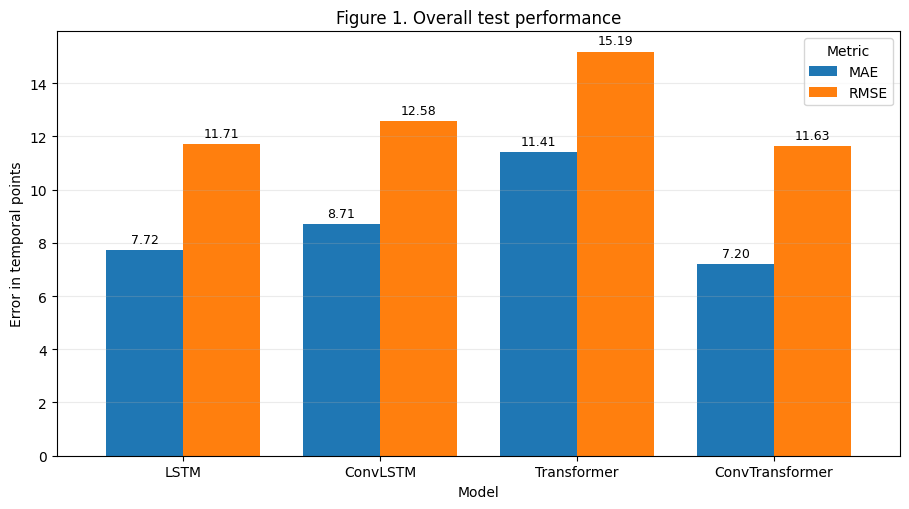

In [2]:

fig, ax = plt.subplots(figsize=(9.2, 5.2))
overall_table.plot(kind="bar", ax=ax, rot=0, width=0.78)
ax.set_xlabel("Model")
ax.set_ylabel("Error in temporal points")
ax.set_title("Figure 1. Overall test performance")
ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_1_overall_test_performance.png", dpi=300)
plt.show()


**Figura 1. Rendimiento global en el conjunto de prueba.** La comparación global resume el error total de cada arquitectura sobre el mismo conjunto de test equilibrado. El modelo **ConvTransformer** obtiene el mejor resultado global, con **MAE = 7.20** y **RMSE = 11.63** puntos temporales. Esto indica que combina de forma eficaz la información local de la trayectoria con relaciones temporales más amplias.

**LSTM** queda muy cerca, con **MAE = 7.72** y **RMSE = 11.71**, por lo que sigue siendo una referencia fuerte y estable para trayectorias cortas. **ConvLSTM** mantiene un rendimiento competitivo, aunque algo superior en error. **Transformer** presenta los errores más altos en esta configuración, lo que sugiere que la atención pura, sin el apoyo de una extracción local previa, tiene más dificultad para este conjunto de trayectorias de longitud $L=100$.

La diferencia entre MAE y RMSE también es útil: cuando el RMSE aumenta más que el MAE, significa que aparecen errores grandes en algunas trayectorias concretas. Por eso se analizan también las transiciones ordenadas y no solo el promedio global.


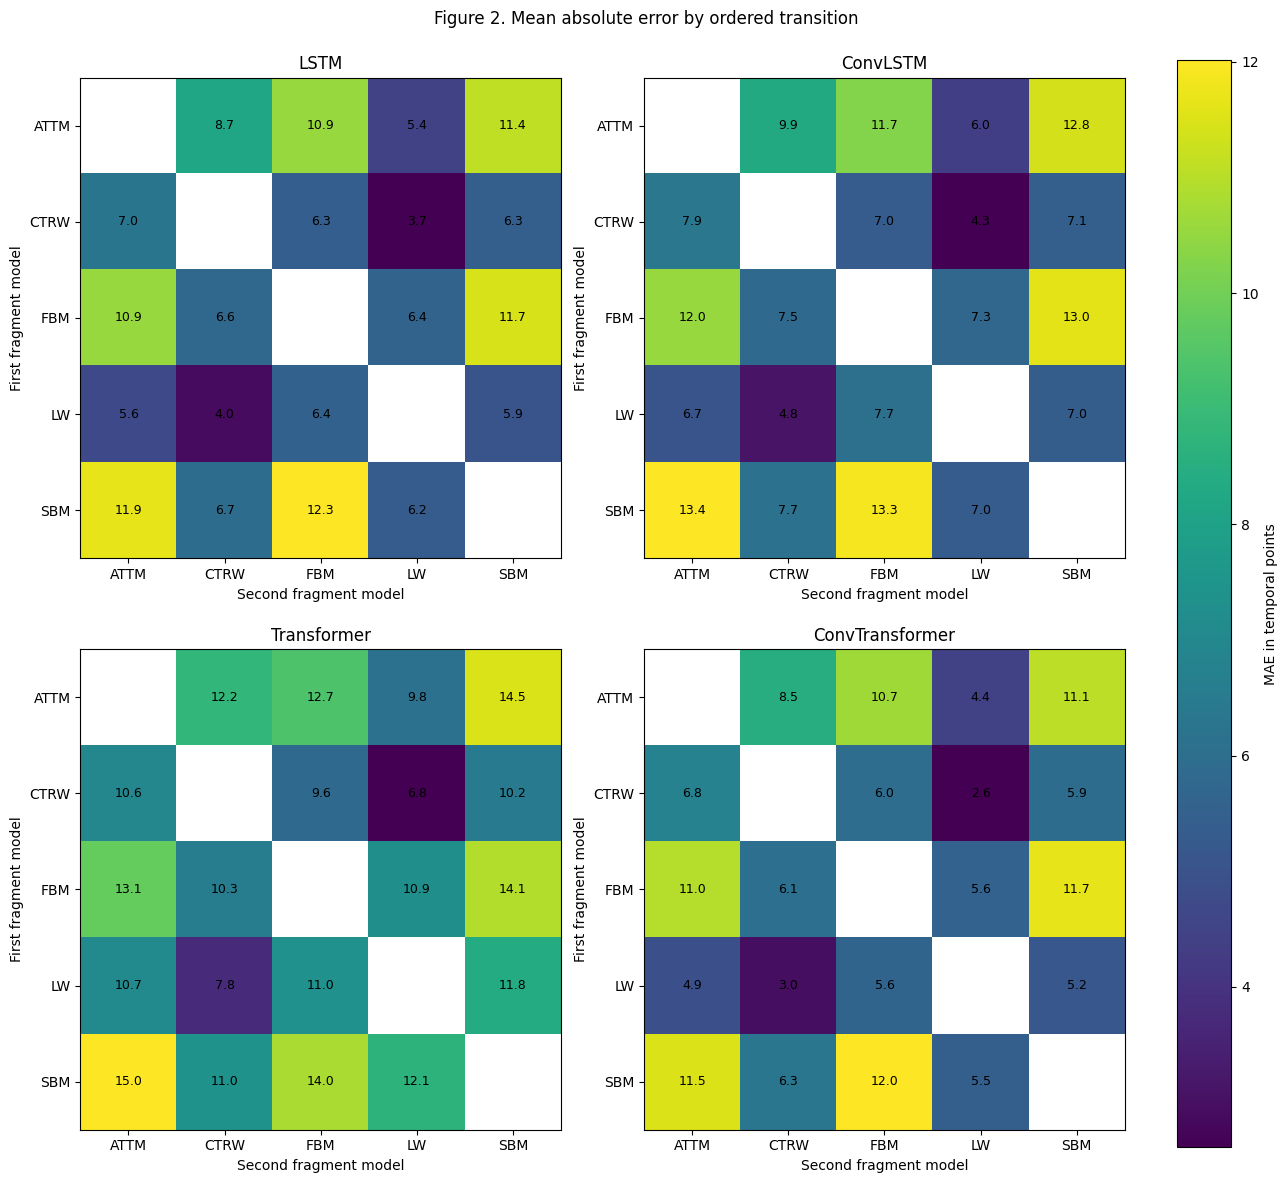

In [3]:

n_models = len(MODEL_ORDER)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.8, 5.7 * nrows), constrained_layout=True)
axes = np.ravel(axes)
last_image = None

for ax, model_name in zip(axes, MODEL_ORDER):
    frame = pair_metrics[pair_metrics["model"] == model_name]
    heatmap = pd.DataFrame(np.nan, index=DIFFUSION_MODELS, columns=DIFFUSION_MODELS)
    for _, row in frame.iterrows():
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]
    last_image = ax.imshow(heatmap.values.astype(float))
    ax.set_xticks(range(len(DIFFUSION_MODELS)))
    ax.set_yticks(range(len(DIFFUSION_MODELS)))
    ax.set_xticklabels(DIFFUSION_MODELS)
    ax.set_yticklabels(DIFFUSION_MODELS)
    ax.set_xlabel("Second fragment model")
    ax.set_ylabel("First fragment model")
    ax.set_title(model_name)
    for i in range(len(DIFFUSION_MODELS)):
        for j in range(len(DIFFUSION_MODELS)):
            value = heatmap.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=9)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Figure 2. Mean absolute error by ordered transition", y=1.03)
fig.colorbar(last_image, ax=axes[:n_models], label="MAE in temporal points")
plt.savefig(FIG_DIR / "figure_2_mae_by_ordered_transition.png", dpi=300, bbox_inches="tight")
plt.show()


**Figura 2. Error absoluto medio por transición ordenada.** Cada celda representa una transición $M_1 \rightarrow M_2$. Las filas indican el modelo de difusión usado en el primer fragmento y las columnas indican el modelo usado en el segundo fragmento. Así se responde directamente a la solicitud de revisar cada caso, por ejemplo **ATTM → CTRW**, **CTRW → LW** o **FBM → SBM**.

Las matrices muestran que la dificultad no es uniforme. Las transiciones entre **CTRW** y **LW** suelen producir los errores más bajos, especialmente **CTRW → LW** y **LW → CTRW**. En el ConvTransformer, estas dos transiciones alcanzan los valores más pequeños del conjunto, lo que confirma que ese cambio de régimen es más fácil de localizar.

En cambio, las transiciones que incluyen **ATTM**, **FBM** o **SBM** tienden a ser más complejas. En esos casos, los dos fragmentos pueden ser visualmente parecidos o presentar diferencias estadísticas menos evidentes en una trayectoria corta. Por esta razón, el punto de cambio no siempre aparece como una ruptura clara y el error de localización aumenta.


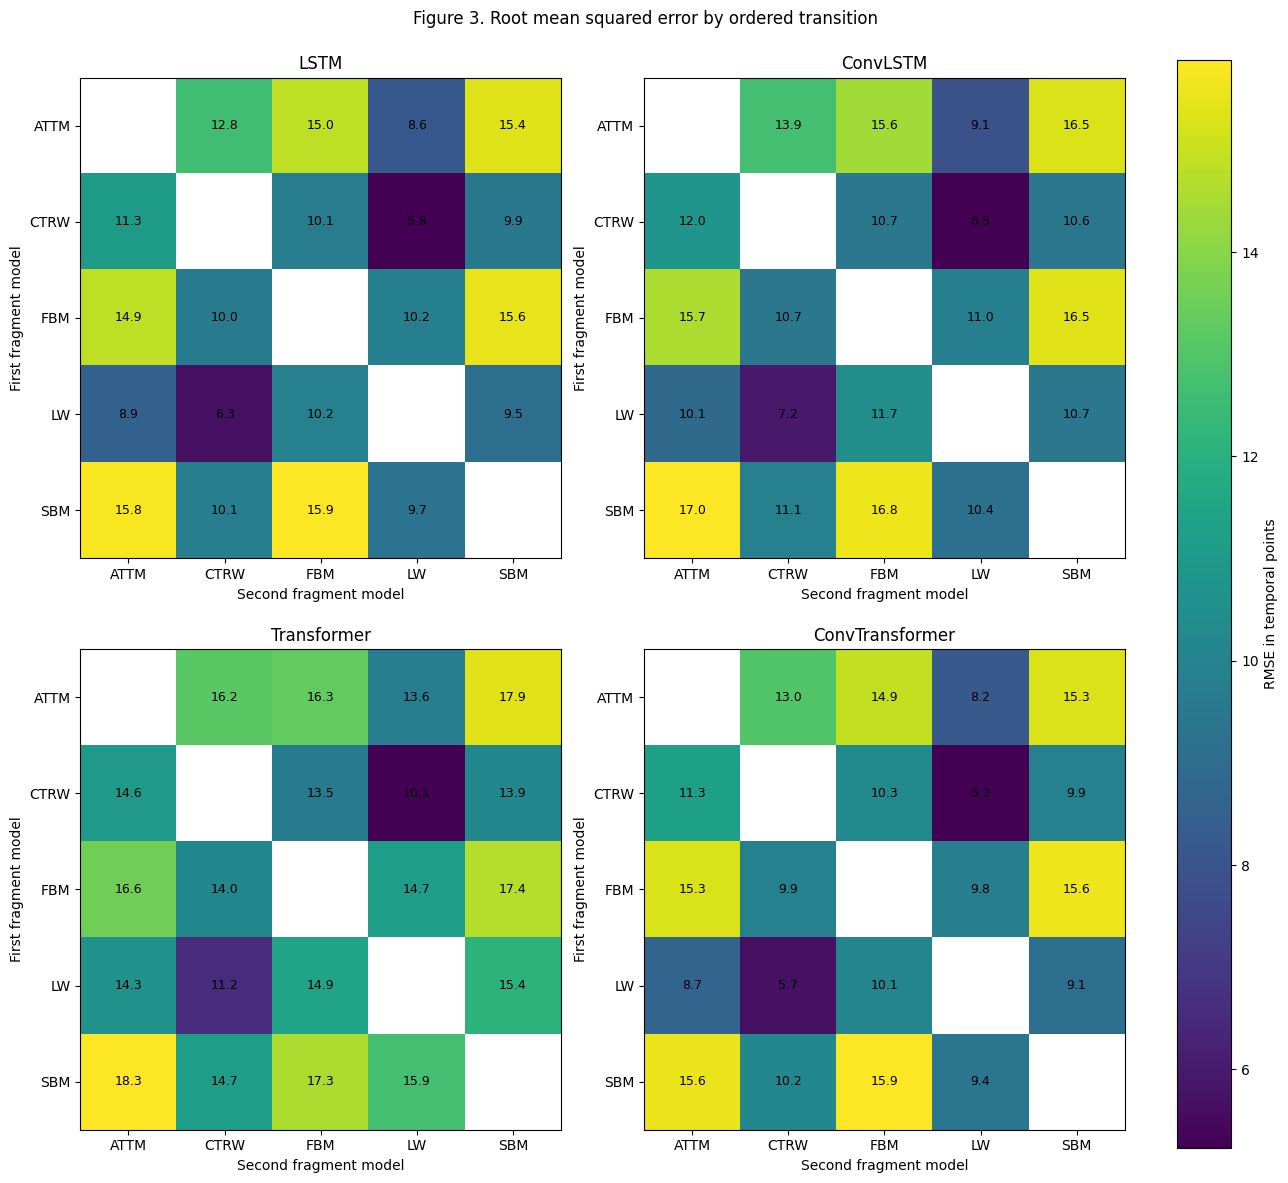

In [4]:

n_models = len(MODEL_ORDER)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.8, 5.7 * nrows), constrained_layout=True)
axes = np.ravel(axes)
last_image = None

for ax, model_name in zip(axes, MODEL_ORDER):
    frame = pair_metrics[pair_metrics["model"] == model_name]
    heatmap = pd.DataFrame(np.nan, index=DIFFUSION_MODELS, columns=DIFFUSION_MODELS)
    for _, row in frame.iterrows():
        heatmap.loc[row["model1"], row["model2"]] = row["rmse"]
    last_image = ax.imshow(heatmap.values.astype(float))
    ax.set_xticks(range(len(DIFFUSION_MODELS)))
    ax.set_yticks(range(len(DIFFUSION_MODELS)))
    ax.set_xticklabels(DIFFUSION_MODELS)
    ax.set_yticklabels(DIFFUSION_MODELS)
    ax.set_xlabel("Second fragment model")
    ax.set_ylabel("First fragment model")
    ax.set_title(model_name)
    for i in range(len(DIFFUSION_MODELS)):
        for j in range(len(DIFFUSION_MODELS)):
            value = heatmap.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=9)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Figure 3. Root mean squared error by ordered transition", y=1.03)
fig.colorbar(last_image, ax=axes[:n_models], label="RMSE in temporal points")
plt.savefig(FIG_DIR / "figure_3_rmse_by_ordered_transition.png", dpi=300, bbox_inches="tight")
plt.show()


**Figura 3. RMSE por transición ordenada.** Esta figura repite el análisis por pareja de modelos usando RMSE. La lectura es complementaria a la Figura 2. Si una transición tiene un MAE moderado pero un RMSE elevado, significa que muchas predicciones son razonables, aunque algunas trayectorias generan errores grandes.

Las matrices de RMSE confirman el mismo patrón general: **ConvTransformer** y **LSTM** son las arquitecturas más sólidas en esta comparación, mientras que **ConvLSTM** mantiene un comportamiento intermedio y **Transformer** concentra errores más altos en las transiciones difíciles.

Este análisis permite detectar no solo qué modelo tiene menor error global, sino también en qué parejas de difusión se producen los errores más severos.


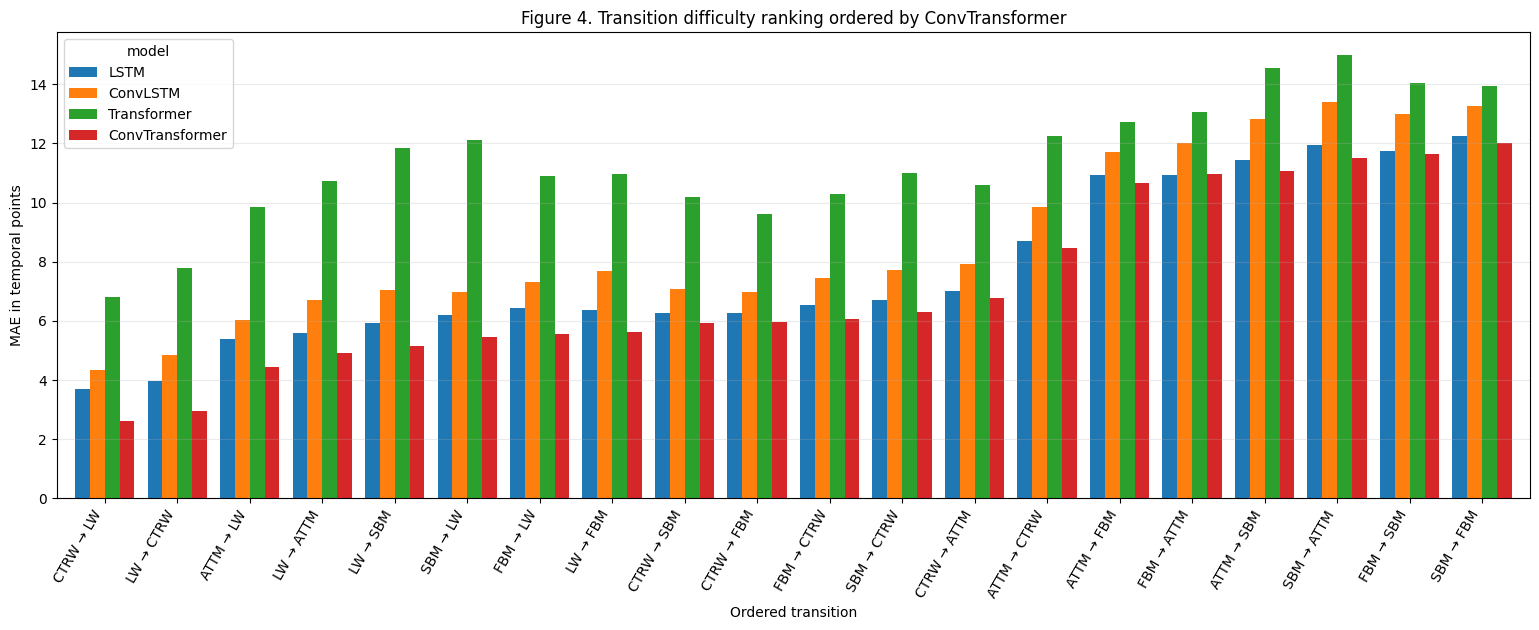

In [5]:

ranking_order = (
    pair_metrics[pair_metrics["model"] == REFERENCE_MODEL]
    .sort_values("mae")["transition"]
    .tolist()
)
ranking_table = (
    pair_metrics
    .pivot(index="transition", columns="model", values="mae")
    .reindex(ranking_order)[MODEL_ORDER]
)
fig, ax = plt.subplots(figsize=(15.5, 6.4))
ranking_table.plot(kind="bar", ax=ax, width=0.82)
ax.set_xlabel("Ordered transition")
ax.set_ylabel("MAE in temporal points")
ax.set_title(f"Figure 4. Transition difficulty ranking ordered by {REFERENCE_MODEL}")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_4_transition_difficulty_ranking.png", dpi=300)
plt.show()


**Figura 4. Ranking de dificultad de las transiciones.** Las transiciones se ordenan según el MAE obtenido por **ConvTransformer**, ya que es el modelo con menor error global en esta comparación final. En el mismo orden se muestran los errores de **LSTM**, **ConvLSTM** y **Transformer**.

El ranking muestra que los cuatro modelos siguen una tendencia parecida: las transiciones fáciles para ConvTransformer también suelen ser relativamente fáciles para LSTM y ConvLSTM. Por tanto, la dificultad no depende únicamente de la arquitectura, sino también de la relación entre los dos modelos de difusión que forman la trayectoria.

Los casos más favorables se concentran en transiciones asociadas a **CTRW** y **LW**. Los casos más desfavorables aparecen con mayor frecuencia alrededor de **ATTM**, **FBM** y **SBM**, donde las diferencias entre fragmentos pueden ser más sutiles.


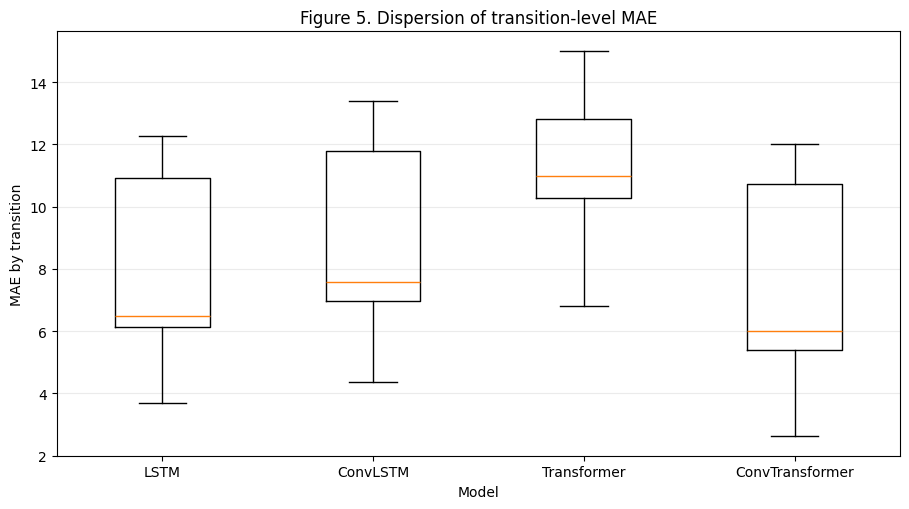

In [6]:

transition_mae_data = [
    pair_metrics.loc[pair_metrics["model"] == model_name, "mae"].dropna().values
    for model_name in MODEL_ORDER
]
fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.boxplot(transition_mae_data, tick_labels=MODEL_ORDER, showfliers=False)
ax.set_xlabel("Model")
ax.set_ylabel("MAE by transition")
ax.set_title("Figure 5. Dispersion of transition-level MAE")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_5_transition_level_mae_dispersion.png", dpi=300)
plt.show()


**Figura 5. Dispersión del MAE por transición.** Este diagrama de cajas resume cómo se distribuyen los errores medios de las 20 transiciones para cada arquitectura. A diferencia de la métrica global, esta figura muestra si un modelo mantiene un comportamiento regular entre parejas de difusión o si depende mucho del tipo de transición.

Una caja más compacta indica que el modelo tiene un rendimiento más uniforme entre transiciones. Una caja más amplia indica mayor variabilidad: el modelo puede funcionar muy bien en algunas parejas y fallar más en otras.

**ConvTransformer** y **LSTM** muestran las distribuciones más favorables en esta comparación. **ConvLSTM** conserva un patrón cercano, mientras que **Transformer** presenta una dispersión más alta, coherente con sus mayores errores globales y por transición.


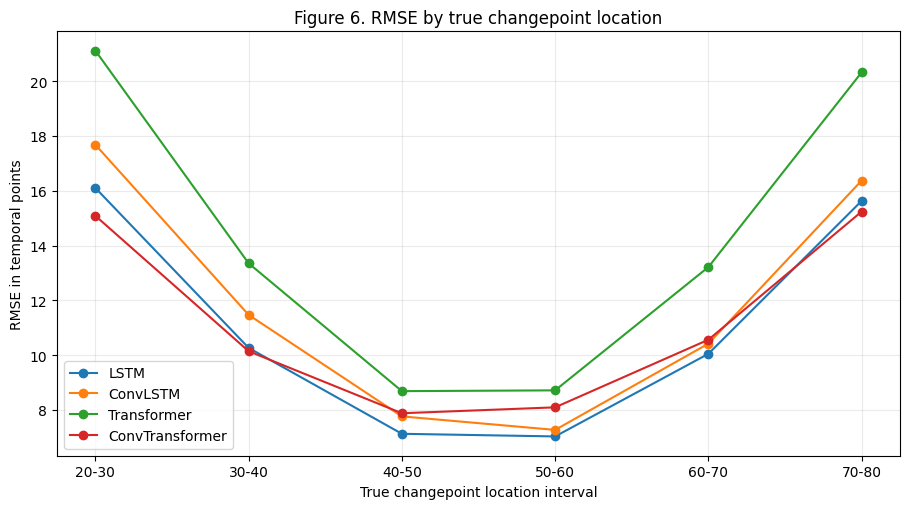

,LSTM,ConvLSTM,Transformer,ConvTransformer
true_changepoint_bin,,,,
20-30,16.102382,17.678615,21.109954,15.085416
30-40,10.266174,11.470755,13.351886,10.144525
40-50,7.131464,7.766349,8.687420,7.881438
50-60,7.035207,7.273314,8.716018,8.096429
60-70,10.049839,10.420568,13.214977,10.563757
70-80,15.629327,16.371558,20.319517,15.238751


In [7]:
used_prediction_files_for_location = False

if not prediction_frame.empty:
    bins = np.arange(MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH + 10, 10)
    bin_labels = [f"{int(bins[i])}-{int(bins[i + 1])}" for i in range(len(bins) - 1)]
    rmse_by_location_frames = []
    for model_name in MODEL_ORDER:
        model_predictions = prediction_frame[prediction_frame["model"] == model_name].copy()
        if model_predictions.empty:
            continue
        model_predictions["true_changepoint_bin"] = pd.cut(
            model_predictions["true_changepoint"],
            bins=bins,
            labels=bin_labels,
            include_lowest=True,
            right=True,
        )
        grouped = model_predictions.groupby("true_changepoint_bin", observed=False)["error"].apply(
            lambda values: float(np.sqrt(np.mean(np.square(values))))
        )
        rmse_by_location_frames.append(grouped.rename(model_name))
    if rmse_by_location_frames:
        rmse_by_location = pd.concat(rmse_by_location_frames, axis=1)
        used_prediction_files_for_location = set(MODEL_ORDER).issubset(set(rmse_by_location.columns))
    else:
        rmse_by_location = embedded_rmse_location.copy()
else:
    rmse_by_location = embedded_rmse_location.copy()

fig, ax = plt.subplots(figsize=(9.2, 5.2))
rmse_by_location.plot(marker="o", ax=ax)
ax.set_xlabel("True changepoint location interval")
ax.set_ylabel("RMSE in temporal points")
ax.set_title("Figure 6. RMSE by true changepoint location")
ax.grid(alpha=0.25)

missing_location_models = [model_name for model_name in MODEL_ORDER if model_name not in rmse_by_location.columns]
if missing_location_models:
    missing_text = "Missing location curve: " + ", ".join(missing_location_models) + "\nRequires *_test_predictions.csv"
    ax.text(
        0.02,
        0.98,
        missing_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.15),
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_6_rmse_by_true_changepoint_location.png", dpi=300)
plt.show()

rmse_by_location

**Figura 6. RMSE según la posición real del punto de cambio.** Esta figura comprueba si el error depende de la ubicación real del cambio dentro de la trayectoria. El patrón esperado es que el error aumente cerca de los extremos, porque uno de los dos segmentos queda demasiado corto para describir bien su dinámica.

Cuando los archivos `*_test_predictions.csv` están disponibles, la tabla se recalcula automáticamente para todos los modelos, incluido **ConvTransformer**. Si esos archivos no están presentes, el notebook utiliza una tabla precalculada disponible para los modelos anteriores y conserva el código preparado para actualizar la figura al ejecutar el proyecto completo.

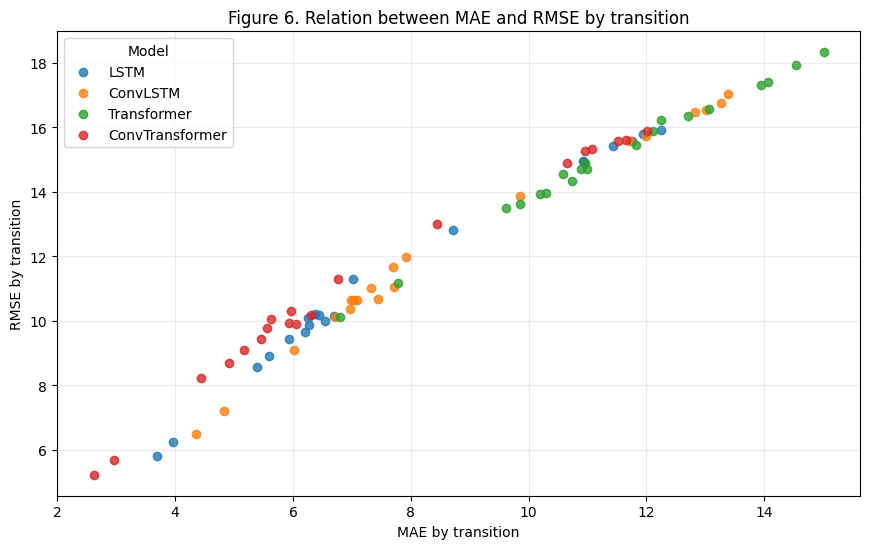

In [8]:

fig, ax = plt.subplots(figsize=(8.8, 5.6))
for model_name in MODEL_ORDER:
    frame = pair_metrics[pair_metrics["model"] == model_name]
    ax.scatter(frame["mae"], frame["rmse"], label=model_name, alpha=0.8)
ax.set_xlabel("MAE by transition")
ax.set_ylabel("RMSE by transition")
ax.set_title("Figure 6. Relation between MAE and RMSE by transition")
ax.grid(alpha=0.25)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_7_mae_rmse_relation_by_transition.png", dpi=300)
plt.show()


**Figura 7. Relación entre MAE y RMSE por transición.** Cada punto representa una transición ordenada para un modelo concreto. Esta figura permite observar si una arquitectura mantiene una relación estable entre el error medio y los errores grandes.

Cuando un punto se sitúa cerca de valores bajos tanto en MAE como en RMSE, la transición es relativamente fácil. Cuando el RMSE crece mucho respecto al MAE, significa que existen trayectorias con errores más severos dentro de esa transición.

La nube de puntos confirma que **ConvTransformer** y **LSTM** concentran varias transiciones en la zona de menor error. **Transformer** aparece con más frecuencia en valores altos, especialmente en transiciones complejas. Esta lectura complementa las matrices porque resume la severidad de los errores sin perder la separación por tipo de transición.


In [9]:
def load_test_trajectories(data_dir=DATA_DIR):
    h5_path = Path(data_dir) / "test_L100_dim1.h5"
    if not h5_path.exists():
        raise FileNotFoundError(f"Raw test file not found: {h5_path}")
    with h5py.File(h5_path, "r") as file:
        trajectories = file["X"][:].astype("float32")
    if trajectories.ndim == 2:
        trajectories = trajectories[:, :, None]
    trajectories = (trajectories - trajectories.mean(axis=1, keepdims=True)) / (
        trajectories.std(axis=1, keepdims=True) + 1e-8
    )
    return trajectories


def representative_index_for_pair(frame, model1, model2):
    subset = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]
    if subset.empty:
        return None
    median_error = subset["absolute_error"].median()
    return int((subset["absolute_error"] - median_error).abs().idxmin())


def plot_transition_panel(model_name, trajectories, save=True):
    model_predictions = prediction_frame[prediction_frame["model"] == model_name].reset_index(drop=True)
    if model_predictions.empty:
        return
    ncols = 4
    nrows = int(np.ceil(len(ORDERED_TRANSITIONS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = axes.ravel()
    for panel_index, (model1, model2) in enumerate(ORDERED_TRANSITIONS):
        ax = axes[panel_index]
        row_index = representative_index_for_pair(model_predictions, model1, model2)
        if row_index is None:
            ax.axis("off")
            ax.set_title(f"{model1} → {model2}\\nNo data")
            continue
        row = model_predictions.loc[row_index]
        trajectory = trajectories[row_index, :, 0]
        true_cp = int(row["true_changepoint"])
        predicted_cp = float(row.get("predicted_changepoint_continuous", row["predicted_changepoint"]))
        absolute_error = float(row["absolute_error"])
        ax.plot(trajectory, linewidth=1.2)
        ax.axvline(true_cp, linestyle="--", linewidth=1.5, label="true")
        ax.axvline(predicted_cp, linestyle="-", linewidth=1.5, label="predicted")
        ax.set_title(f"{model1} → {model2}\\ntrue={true_cp}, predicted={predicted_cp:.1f}, error={absolute_error:.0f}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Normalized trajectory")
    for empty_ax in axes[len(ORDERED_TRANSITIONS):]:
        empty_ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(f"Figure 8. True and predicted changepoints by ordered transition: {model_name}", y=1.02)
    plt.tight_layout()
    if save:
        filename = f"figure_8_transition_panel_{model_name.lower()}.png"
        plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

if not prediction_frame.empty and (DATA_DIR / "test_L100_dim1.h5").exists():
    trajectories = load_test_trajectories(DATA_DIR)
    for selected_model in MODEL_ORDER:
        plot_transition_panel(selected_model, trajectories)
else:
    for selected_model in MODEL_ORDER:
        cached_path_candidates = [
            PROJECT_ROOT / f"panel_{selected_model}.png",
            PROJECT_ROOT / "figures" / f"panel_{selected_model}.png",
            Path("/mnt/data") / f"panel_{selected_model}.png",
        ]
        cached_path = next((path for path in cached_path_candidates if path.exists()), None)
        if cached_path is not None:
            display(Image(filename=str(cached_path), width=1100))


**Figura 8. Puntos de cambio reales y predichos por transición ordenada.** Los paneles de trayectorias proporcionan la validación visual solicitada para cada transición $M_1 \rightarrow M_2$. La línea vertical discontinua marca el punto real $\tau$, mientras que la línea vertical continua marca la predicción $\hat{\tau}$.

Cada subfigura representa una trayectoria de prueba seleccionada para una pareja ordenada. Cuando las dos líneas verticales aparecen próximas, el modelo ha localizado correctamente la transición. Cuando están separadas, el ejemplo corresponde a una situación más difícil: la transición puede ser suave, los fragmentos pueden ser estadísticamente parecidos o uno de los segmentos puede contener poca información.

Esta celda puede regenerar los paneles para los cuatro modelos si están disponibles los archivos `*_test_predictions.csv` y el archivo `test_L100_dim1.h5`. Si esos archivos no están en el repositorio, las figuras globales y por transición anteriores siguen funcionando con las métricas embebidas en este cuaderno.


## Interpretación final

La validación final muestra que **ConvTransformer** obtiene el mejor rendimiento global, con **MAE = 7.20** y **RMSE = 11.63** puntos temporales. Este resultado se explica por la combinación de información local, construida a partir de canales derivados de la trayectoria, con mecanismos de atención capaces de comparar posiciones separadas dentro de la misma secuencia.

**LSTM** queda muy cerca de ConvTransformer y continúa siendo una arquitectura sólida para trayectorias cortas de longitud $L=100$. **ConvLSTM** también ofrece resultados competitivos, aunque con un error algo mayor. **Transformer**, en esta configuración concreta, presenta el rendimiento global más débil de los cuatro modelos.

La comparación no debe basarse únicamente en una métrica global. Las matrices por transición muestran que la dificultad depende de la pareja $M_1 \rightarrow M_2$: las transiciones relacionadas con **CTRW** y **LW** suelen ser más sencillas, mientras que las combinaciones que incluyen **ATTM**, **FBM** y **SBM** tienden a producir errores más altos.

El análisis del RMSE según la posición real del punto de cambio añade otra información relevante: los cambios cercanos a los extremos de la trayectoria son más difíciles porque uno de los dos fragmentos contiene menos puntos. Por eso, además de comparar modelos, es importante observar cómo se comportan según la transición y según la localización del cambio.

En conjunto, los resultados responden a la solicitud de validación: los modelos se entrenaron con **200.000 trayectorias**, se validaron con **20.000 trayectorias** y se evaluaron con **10.000 trayectorias por cada transición ordenada**. La comparación global, las matrices por transición, el análisis por localización y los paneles de puntos reales y predichos permiten decidir qué resultados incluir en la versión final del proyecto.
